In [1]:
# Load and inspect the dataset, then apply binning, summarize, and propose a balanced 30-image subset.
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
all_naps_ratings_path = "C:\\Users\\fkamdar\\Desktop\\repos\\pd_nonmotor\\stimuli\\all_NAPs_ratings.csv"
all_naps_ratings = pd.read_csv(all_naps_ratings_path)

all_iaps_ratings_path = "C:\\Users\\fkamdar\\Desktop\\repos\\pd_nonmotor\\stimuli\\all_IAPs_ratings.csv"
all_iaps_ratings = pd.read_csv(all_iaps_ratings_path)

Text(0.5, 1.0, 'Valence Rating Distribution for NAPs')

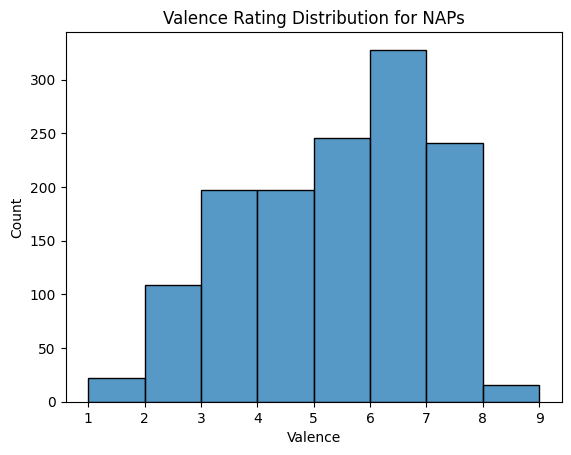

In [6]:
# Plot histograms of valence rating distributions for 1:1:9 bins
sns.histplot(all_naps_ratings['Valence'], bins=[1, 2, 3, 4, 5, 6, 7, 8, 9], kde=False)
plt.title('Valence Rating Distribution for NAPs')


Text(0.5, 1.0, 'Valence Rating Distribution for IAPs')

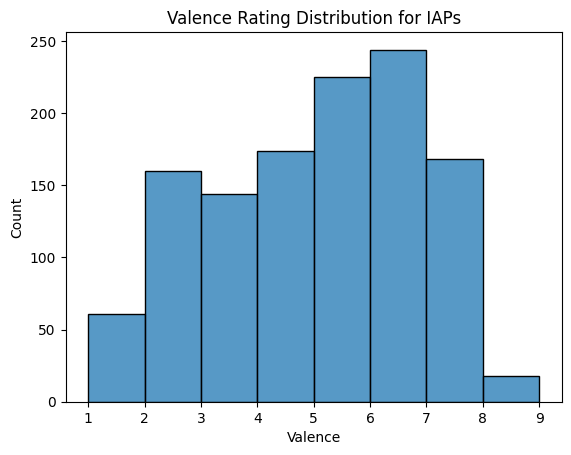

In [7]:
sns.histplot(all_iaps_ratings['Valence'], bins=[1, 2, 3, 4, 5, 6, 7, 8, 9], kde=False)
plt.title('Valence Rating Distribution for IAPs')

Text(0.5, 1.0, 'Valence Rating Distribution for Combined Ratings')

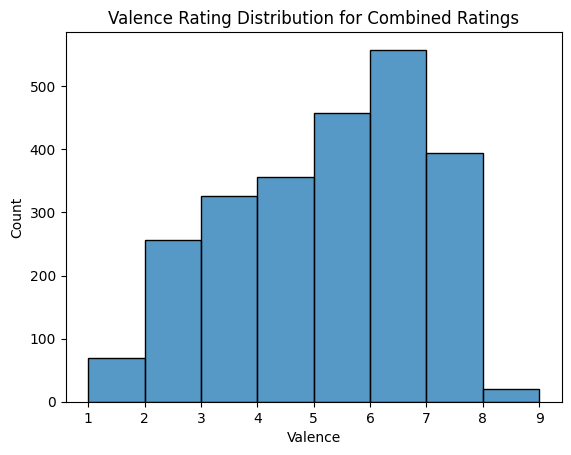

In [13]:
# Combine both the datatsets for a comprehensive view
all_naps_postsession1_path = r"C:\Users\fkamdar\Desktop\repos\pd_nonmotor\stimuli\all_NAPs_ratings_postSession1.csv"
all_naps_ratings = pd.read_csv(all_naps_postsession1_path)
combined_ratings = pd.concat([all_naps_ratings, all_iaps_ratings], ignore_index=True)
sns.histplot(combined_ratings['Valence'], bins=[1, 2, 3, 4, 5, 6, 7, 8, 9], kde=False)
plt.title('Valence Rating Distribution for Combined Ratings')




In [14]:
# Divide combined dataset into 8 bins (1-2, 2-3, ..., 8-9) for use across 5 sessions with max 14 in each bin

# Define bin edges for 8 bins: [1-2), [2-3), [3-4), [4-5), [5-6), [6-7), [7-8), [8-9]
bin_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9]
bin_labels = [f'{bin_edges[i]}-{bin_edges[i+1]}' for i in range(len(bin_edges)-1)]

# Assign each image to a bin based on valence
combined_ratings['Valence_Bin'] = pd.cut(combined_ratings['Valence'], bins=bin_edges, labels=bin_labels, include_lowest=True, right=False)

# Create a summary of bin counts
bin_summary = combined_ratings['Valence_Bin'].value_counts().sort_index()
print("Bin Summary (before limiting to 14):")
print(bin_summary)
print(f"\nTotal images: {len(combined_ratings)}")

# For each bin, limit to maximum 14 items and sample if necessary
max_per_bin = 14
binned_data = []

for bin_label in bin_labels:
    bin_data = combined_ratings[combined_ratings['Valence_Bin'] == bin_label]
    
    if len(bin_data) > max_per_bin:
        # Randomly sample max_per_bin items from this bin
        bin_data_sampled = bin_data.sample(n=max_per_bin, random_state=42)
    else:
        bin_data_sampled = bin_data
    
    binned_data.append(bin_data_sampled)
    print(f"Bin {bin_label}: {len(bin_data_sampled)} items (original: {len(bin_data)})")

# Combine all binned data
balanced_binned_data = pd.concat(binned_data, ignore_index=True)

print(f"\nTotal images after binning and limiting: {len(balanced_binned_data)}")
print(f"This gives {len(balanced_binned_data) / 5:.1f} images per session on average")

# Display the final bin distribution
print("\nFinal Bin Distribution:")
print(balanced_binned_data['Valence_Bin'].value_counts().sort_index())

Bin Summary (before limiting to 14):
Valence_Bin
1-2     69
2-3    256
3-4    326
4-5    357
5-6    457
6-7    558
7-8    395
8-9     20
Name: count, dtype: int64

Total images: 2438
Bin 1-2: 14 items (original: 69)
Bin 2-3: 14 items (original: 256)
Bin 3-4: 14 items (original: 326)
Bin 4-5: 14 items (original: 357)
Bin 5-6: 14 items (original: 457)
Bin 6-7: 14 items (original: 558)
Bin 7-8: 14 items (original: 395)
Bin 8-9: 14 items (original: 20)

Total images after binning and limiting: 112
This gives 22.4 images per session on average

Final Bin Distribution:
Valence_Bin
1-2    14
2-3    14
3-4    14
4-5    14
5-6    14
6-7    14
7-8    14
8-9    14
Name: count, dtype: int64


In [ ]:
session2_naps_path = r"C:\Users\fkamdar\Desktop\repos\pd_nonmotor\stimuli\blocks\pndm01_block_112.csv"
session2_naps = pd.read_csv(session2_naps_path)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(session2_naps["Valence"], bins=20)
plt.xlim(1,9)
plt.xlabel("Valence")
plt.ylabel("Count")
plt.title("All Naps ratings Valence Distribution")
plt.show()

bins = np.linspace(1, 9, 17)  # 16 bins → 17 edges
counts, edges = np.histogram(session2_naps["Valence"], bins=bins)
for i in range(len(counts)):
    print(f"{edges[i]:.2f}–{edges[i+1]:.2f}: {counts[i]}")